# 🔬 Patent Analysis Notebook
This notebook analyzes patent data from a SQLite database and generates visualizations for:
- Top 10 Inventors by Patent Count
- Top 10 Companies by Patent Count
- US Patents Granted Per Year (1976–2025)

## 📦 1. Imports & Setup

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os

DB_PATH = "data/patents.db"
REPORTS = "reports"
os.makedirs(REPORTS, exist_ok=True)

print(f"Database path : {DB_PATH}")
print(f"Reports folder: {REPORTS}")

Database path : data/patents.db
Reports folder: reports


## 🗄️ 2. Load Data from SQLite

In [12]:
import sqlite3

DB_PATH = "/Users/armandshematsi/Desktop/patent-pipeline-clean/data/patents.db"
conn = sqlite3.connect(DB_PATH)
print("Connected to database ✓")

Connected to database ✓


In [13]:
# Top 10 Inventors
top_inventors = pd.read_sql("""
    SELECT name, COUNT(DISTINCT patent_id) AS patents
    FROM inventors WHERE name != ''
    GROUP BY inventor_id
    ORDER BY patents DESC LIMIT 10
""", conn)

print(f"Loaded {len(top_inventors)} inventors")
top_inventors

Loaded 10 inventors


,name,patents
0,Shunpei Yamazaki,6787
1,Kia Silverbrook,4778
2,Tao Luo,4490
3,Jonathan P. Ive,2947
4,Junyi Li,2881
5,Kangguo Cheng,2835
6,"Frederick E. Shelton, IV",2723
7,Peter Gaal,2554
8,Duncan Robert Kerr,2534
9,Bartley K. Andre,2478


In [14]:
# Top 10 Companies
top_companies = pd.read_sql("""
    SELECT name, COUNT(DISTINCT patent_id) AS patents
    FROM companies WHERE name IS NOT NULL
    GROUP BY company_id
    ORDER BY patents DESC LIMIT 10
""", conn)

print(f"Loaded {len(top_companies)} companies")
top_companies

Loaded 10 companies


,name,patents
0,"SAMSUNG DISPLAY CO., LTD.",174536
1,International Business Machines Corporation,164083
2,CANON KABUSHIKI KAISHA,91331
3,SONY GROUP CORPORATION,62911
4,Fujitsu Limited,56343
5,Kabushiki Kaisha Toshiba,53607
6,Intel Corporation,53219
7,General Electric Company,52043
8,LG ELECTRONICS INC.,50000
9,"HITACHI, LTD.",46073


In [15]:
# Patents Per Year
patents_per_year = pd.read_sql("""
    SELECT year, COUNT(*) AS patents
    FROM patents WHERE year IS NOT NULL
    GROUP BY year ORDER BY year ASC
""", conn)

print(f"Loaded data for {len(patents_per_year)} years ({patents_per_year['year'].min()} – {patents_per_year['year'].max()})")
patents_per_year.head()

Loaded data for 50 years (1976 – 2025)


,year,patents
0,1976,70941
1,1977,69820
2,1978,70586
3,1979,52484
4,1980,66212


In [16]:
conn.close()
print("Database connection closed.")

Database connection closed.


## 📊 3. Chart 1 — Top 10 Inventors by Patent Count

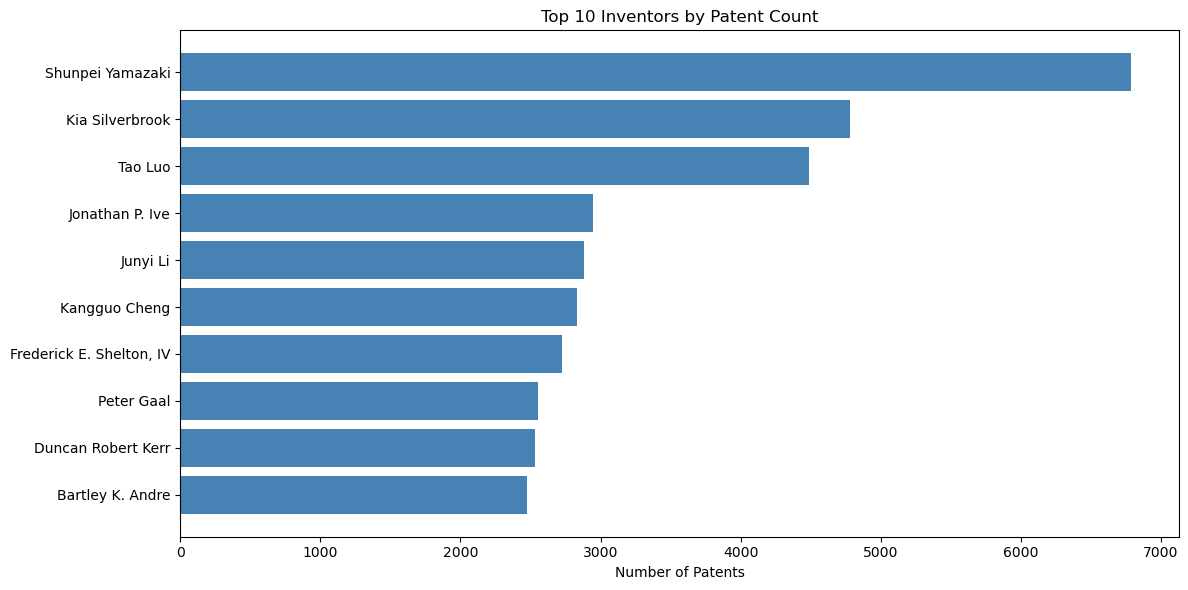

Saved → reports/top_inventors.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    top_inventors["name"][::-1],
    top_inventors["patents"][::-1],
    color="steelblue"
)
ax.set_xlabel("Number of Patents")
ax.set_title("Top 10 Inventors by Patent Count")
plt.tight_layout()

out_path = f"{REPORTS}/top_inventors.png"
plt.savefig(out_path)
plt.show()
print(f"Saved → {out_path}")

## 🏢 4. Chart 2 — Top 10 Companies by Patent Count

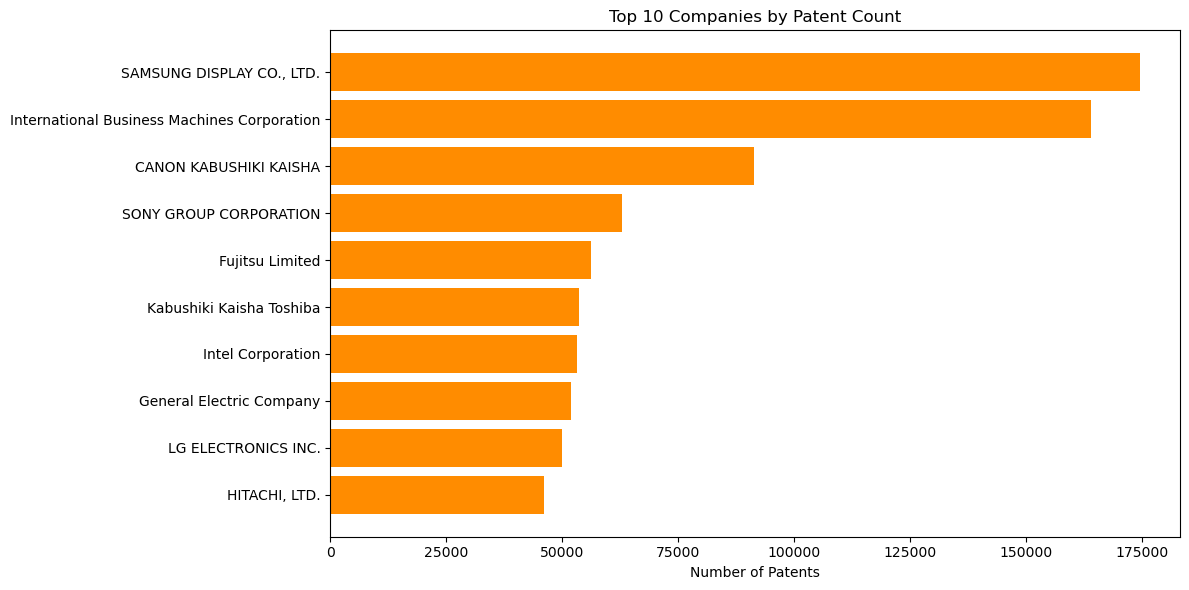

Saved → reports/top_companies.png


In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    top_companies["name"][::-1],
    top_companies["patents"][::-1],
    color="darkorange"
)
ax.set_xlabel("Number of Patents")
ax.set_title("Top 10 Companies by Patent Count")
plt.tight_layout()

out_path = f"{REPORTS}/top_companies.png"
plt.savefig(out_path)
plt.show()
print(f"Saved → {out_path}")

## 📈 5. Chart 3 — US Patents Granted Per Year

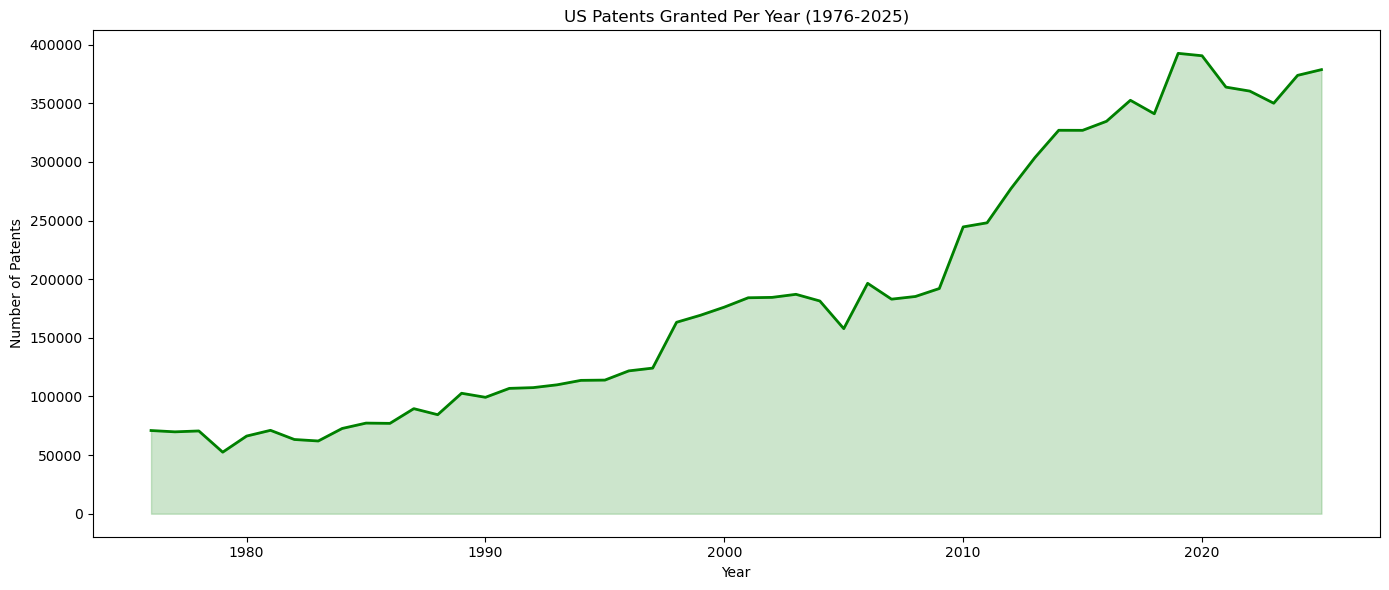

Saved → reports/patents_per_year.png


In [19]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    patents_per_year["year"],
    patents_per_year["patents"],
    color="green",
    linewidth=2
)
ax.fill_between(
    patents_per_year["year"],
    patents_per_year["patents"],
    alpha=0.2,
    color="green"
)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Patents")
ax.set_title("US Patents Granted Per Year (1976-2025)")
plt.tight_layout()

out_path = f"{REPORTS}/patents_per_year.png"
plt.savefig(out_path)
plt.show()
print(f"Saved → {out_path}")

## ✅ 6. Summary

In [20]:
saved = [f for f in os.listdir(REPORTS) if f.endswith(".png")]
print(f"All charts saved to '{REPORTS}/'")
for f in sorted(saved):
    print(f"  ✔ {f}")

All charts saved to 'reports/'
  ✔ patents_per_year.png
  ✔ top_companies.png
  ✔ top_inventors.png


## 🤖 6. Machine Learning — Patent Trend Prediction
In this section, we use **Polynomial Regression** to forecast the number of patents likely to be granted in the coming years based on historical data.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 1. Prepare Data
X = patents_per_year[['year']].values
y = patents_per_year['patents'].values

# 2. Create Polynomial Features (Degree 3 to capture curves)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# 3. Fit Model
model = LinearRegression()
model.fit(X_poly, y)

# 4. Forecast next 10 years
last_year = int(patents_per_year['year'].max())
future_years = np.array([[last_year + i] for i in range(1, 11)])
future_years_poly = poly.transform(future_years)
predictions = model.predict(future_years_poly)

# 5. Create Forecast DataFrame
forecast_df = pd.DataFrame({
    'year': future_years.flatten(),
    'patents': predictions.astype(int)
})

print("Forecast for the next 10 years:")
print(forecast_df)

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(patents_per_year['year'], patents_per_year['patents'], label='Historical Data', marker='o', color='steelblue')
plt.plot(forecast_df['year'], forecast_df['patents'], label='Polynomial Forecast', linestyle='--', marker='s', color='darkorange')
plt.fill_between(forecast_df['year'], forecast_df['patents']*0.9, forecast_df['patents']*1.1, color='orange', alpha=0.2, label='Confidence Interval (Est.)')

plt.title("US Patent Grants: Historical Trend & Future Forecast")
plt.xlabel("Year")
plt.ylabel("Number of Patents")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = "reports/patent_forecast.png"
plt.savefig(out_path)
plt.show()
print(f"Forecast chart saved to {out_path}")